# Checking Correlation of LMArena Dataset

In [1]:
from utils_3 import PairwiseData, Population

In [2]:
import os
for k in ["HF_HOME", "HF_HUB_CACHE", "HF_DATASETS_CACHE", "XDG_CACHE_HOME"]:
    print(k, os.environ.get(k))

HF_HOME /home/jennifer/scratch/hf
HF_HUB_CACHE None
HF_DATASETS_CACHE /home/jennifer/scratch/hf/datasets
XDG_CACHE_HOME None


In [3]:
from datasets import load_dataset

ds = load_dataset(
    "lmarena-ai/arena-human-preference-140k") 
ds = dict(ds)

/home/jennifer/miniconda3/envs/ld/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Question: Does LMArena naturally contain x vs. x pairwise comparions?

In [4]:
# for i in range(len(ds['train'])):
    # if ds['train']['model_a'][i] == ds['train']['model_b'][i]:
        # print(f'same at {i}, {ds["train"]["model_a"][i]}')

Seems like these get filtered out, can ignore.

## Creating the Data, Population

In [5]:
pw = PairwiseData(ds, M=30, N=30)

In [6]:
population = Population(pw)

100%|██████████| 30/30 [00:00<00:00, 34.13it/s]


In [7]:
import matplotlib.pyplot as plt
import numpy as np

In [8]:
candidate_labels = [pw.idx_to_candidates[i] for i in range(len(pw.idx_to_candidates))]

/tmp/ipykernel_303035/1623589895.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


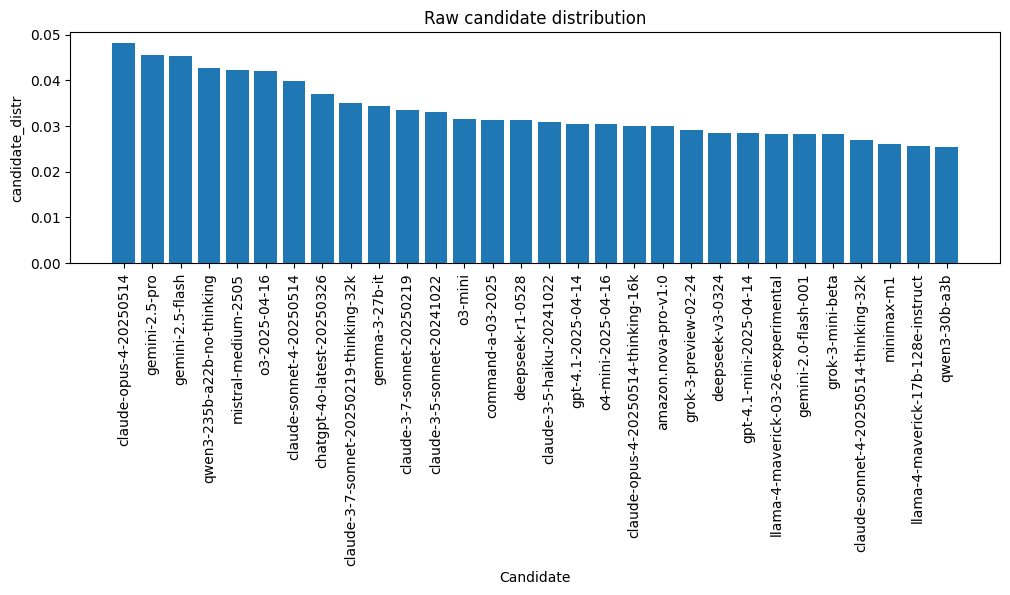

In [9]:
num_subgroups, num_candidates = population.population_utilities.shape
fig, axes = plt.subplots(1, 1, figsize=(12, max(3, 2.5 * 1)), squeeze=False)

for row_idx, ax in enumerate(axes[:, 0]):

    ax.bar(np.arange(num_candidates), pw.candidate_distr)
    ax.set_title(f'Raw candidate distribution')
    ax.set_ylabel('candidate_distr')
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [22]:
pw.candidate_distr.sum()

np.float64(0.9999999999999999)

/tmp/ipykernel_303035/1318931809.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


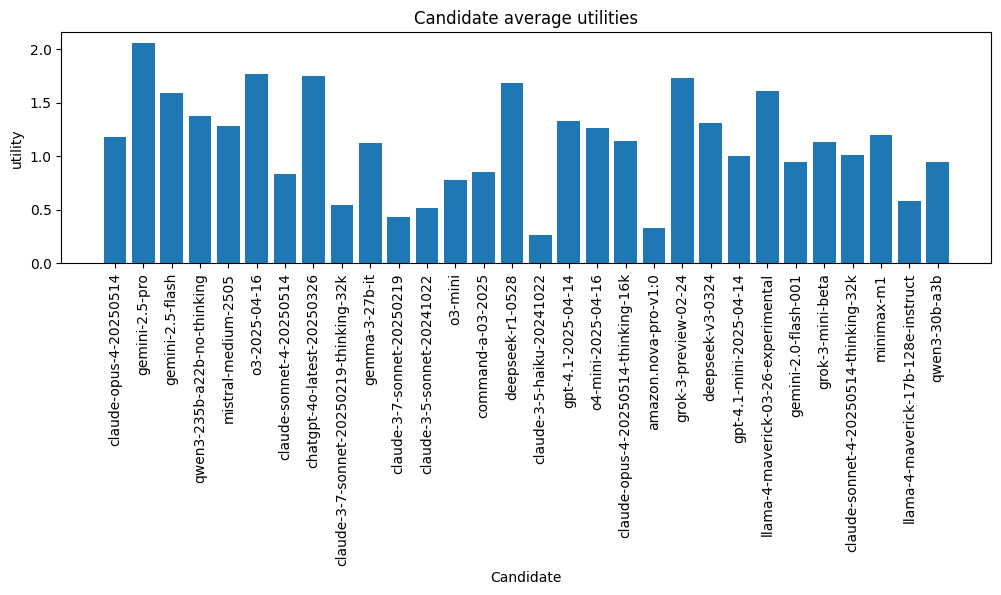

In [10]:
num_subgroups, num_candidates = population.population_utilities.shape
fig, axes = plt.subplots(1, 1, figsize=(12, max(3, 2.5 * 1)), squeeze=False)

for row_idx, ax in enumerate(axes[:, 0]):

    ax.bar(np.arange(num_candidates), population.avg_utilities)
    ax.set_title(f'Candidate average utilities')
    ax.set_ylabel('utility')
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


## Creating unordered pairs distributions

In [58]:
pw.M

30

In [59]:
mu = np.zeros((pw.M, pw.M))

winners = pw.winners
losers = pw.losers
for i in range(len(pw.winners)):
    
    mu[winners[i], losers[i]] += 1.0
    mu[losers[i], winners[i]] += 1.0 # matrix is symmetric

In [60]:
for i in range(len(mu)):
    assert (mu[i, i]) == 0.0

Diagonal is all empty.

In [61]:
# upper triangle excluding diagonal
upper_vals = mu[np.triu_indices(mu.shape[0], k=1)]
upper_vals.sum()

np.float64(37454.0)

In [62]:
pw.winners.shape[0]

37454

In [63]:
mu = mu / pw.winners.shape[0]

In [64]:
mu[np.triu_indices(mu.shape[0], k=1)].sum()

np.float64(1.0)

## Creating the independent distributions

In [25]:

gamma = np.ones(len(mu))

In [26]:
gamma.shape

(30,)

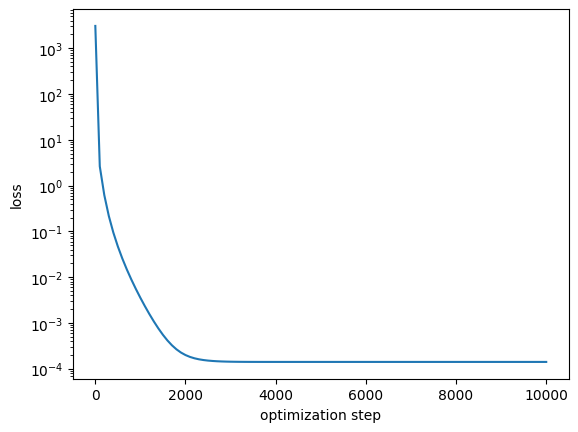

In [65]:
def loss_fn_vector(mu, gamma):
    distr = 2 * np.outer(gamma, gamma)
    np.fill_diagonal(distr, 0.0)
    return ((mu - distr) ** 2).sum()


def learn_gamma_vector(mu, gamma_init=None, num_steps=100_000, lr=0.05, beta1=0.9, beta2=0.999, eps=1e-8, nonnegative=True):
    if gamma_init is None:
        gamma = np.random.default_rng(0).normal(scale=0.1, size=mu.shape[0])
    else:
        gamma = gamma_init.astype(float).copy()

    if nonnegative:
        gamma = np.maximum(gamma, 0.0)

    m = np.zeros_like(gamma)
    v = np.zeros_like(gamma)
    losses = []

    for step in range(1, num_steps + 1): 
        distr = 2 * np.outer(gamma, gamma)
        np.fill_diagonal(distr, 0.0)

        residual = distr - mu
        grad = 8 * residual @ gamma

        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad**2
        m_hat = m / (1 - beta1**step)
        v_hat = v / (1 - beta2**step)

        gamma -= lr * m_hat / (np.sqrt(v_hat) + eps)

        if nonnegative:
            gamma = np.maximum(gamma, 0.0)

        if step == 1 or step % 100 == 0:
            losses.append(loss_fn_vector(mu, gamma.copy()))

    return gamma, np.array(losses)


gamma_init = np.ones(mu.shape[0])
learned_gamma, gamma_losses = learn_gamma_vector(mu, gamma_init, num_steps=10_000, lr=0.03)


# learned_gamma, gamma_losses = learn_gamma(mu, gamma, num_steps=10_000, lr=0.03)

# print(f"initial loss: {loss_fn(mu, gamma.copy()):.2f}")
# print(f"final loss: {loss_fn(mu, learned_gamma.copy()):.2f}")

plt.plot(np.r_[1, np.arange(100, 10_001, 100)], gamma_losses)
plt.xlabel("optimization step")
plt.ylabel("loss")
plt.yscale("log")
plt.show()

/tmp/ipykernel_303035/1963096152.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


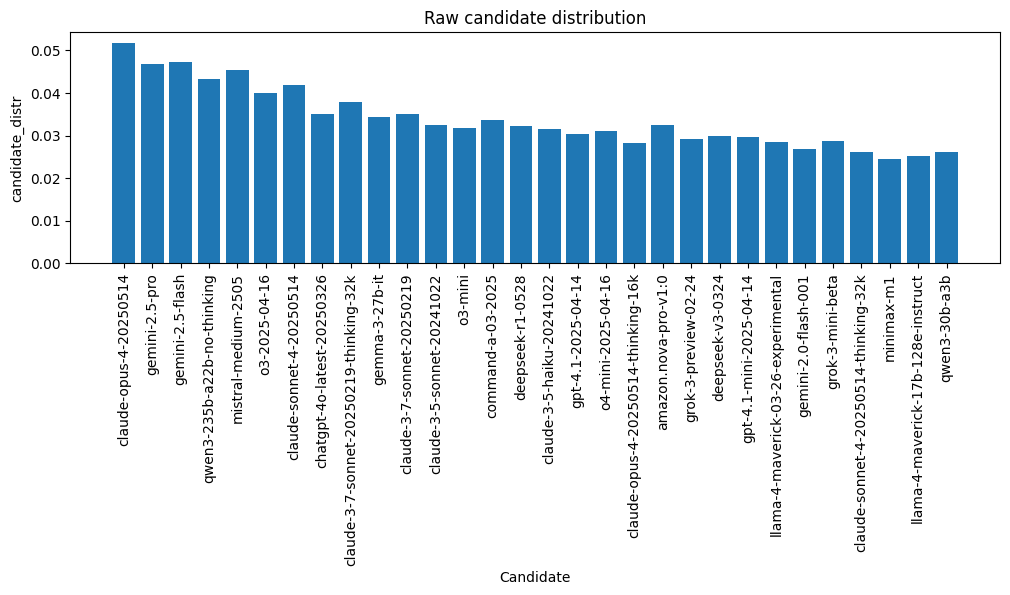

In [67]:
num_subgroups, num_candidates = population.population_utilities.shape
fig, axes = plt.subplots(1, 1, figsize=(12, max(3, 2.5 * 1)), squeeze=False)

for row_idx, ax in enumerate(axes[:, 0]):

    ax.bar(np.arange(num_candidates), learned_gamma)
    ax.set_title(f'Raw candidate distribution')
    ax.set_ylabel('candidate_distr')
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


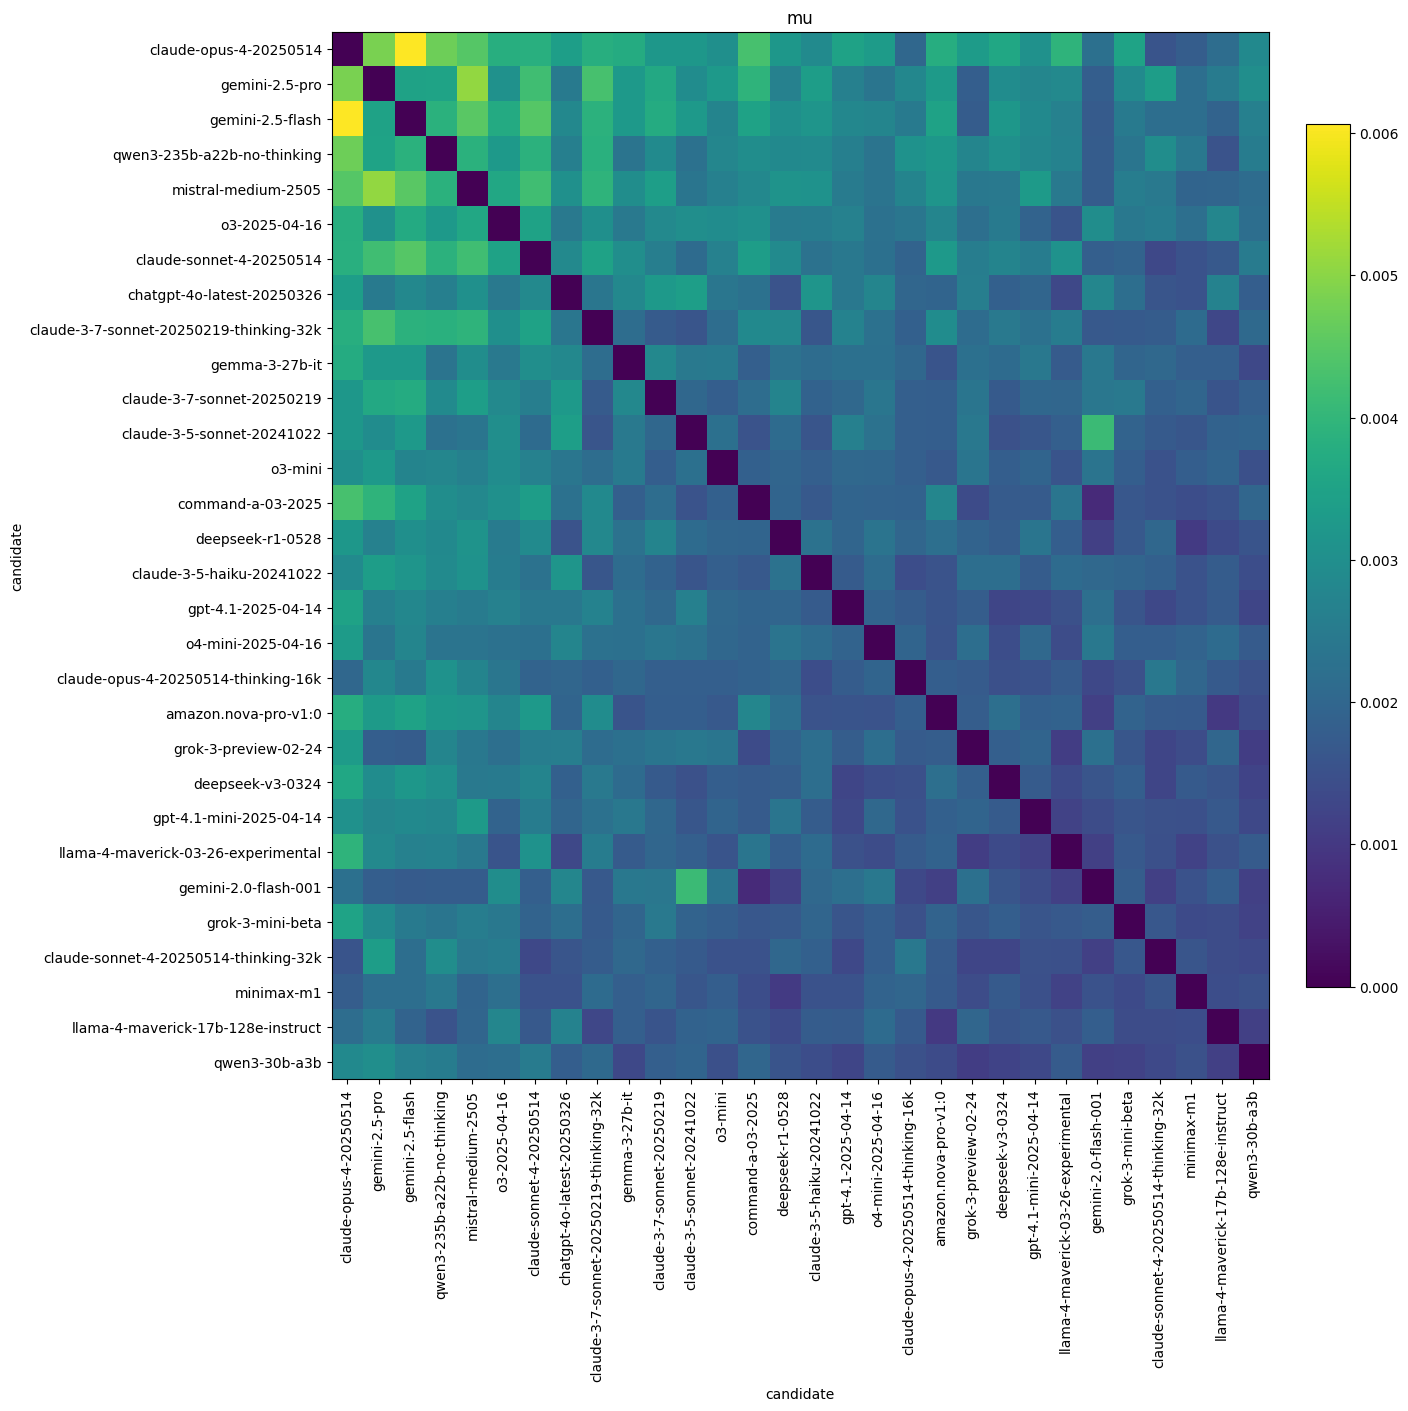

In [73]:
fig, axes = plt.subplots(1, 1, figsize=(14, 14), constrained_layout=True)

matrix = mu
    # (mu, "mu"),
    # (2 * np.outer(learned_gamma, learned_gamma), "learned gamma"),
title = "mu"

# for ax, (matrix, title) in zip(axes, heatmaps):

ax = axes
im = ax.imshow(matrix, cmap="viridis", aspect="auto")
ax.set_title(title)
ax.set_xlabel("candidate")
ax.set_ylabel("candidate")
ax.set_xticks(np.arange(len(candidate_labels)))
ax.set_yticks(np.arange(len(candidate_labels)))
ax.set_xticklabels(candidate_labels, rotation=90)
ax.set_yticklabels(candidate_labels)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

In [ ]:
distr = 2 * np.outer(learned_gamma, learned_gamma)
np.fill_diagonal(distr, 0.0)

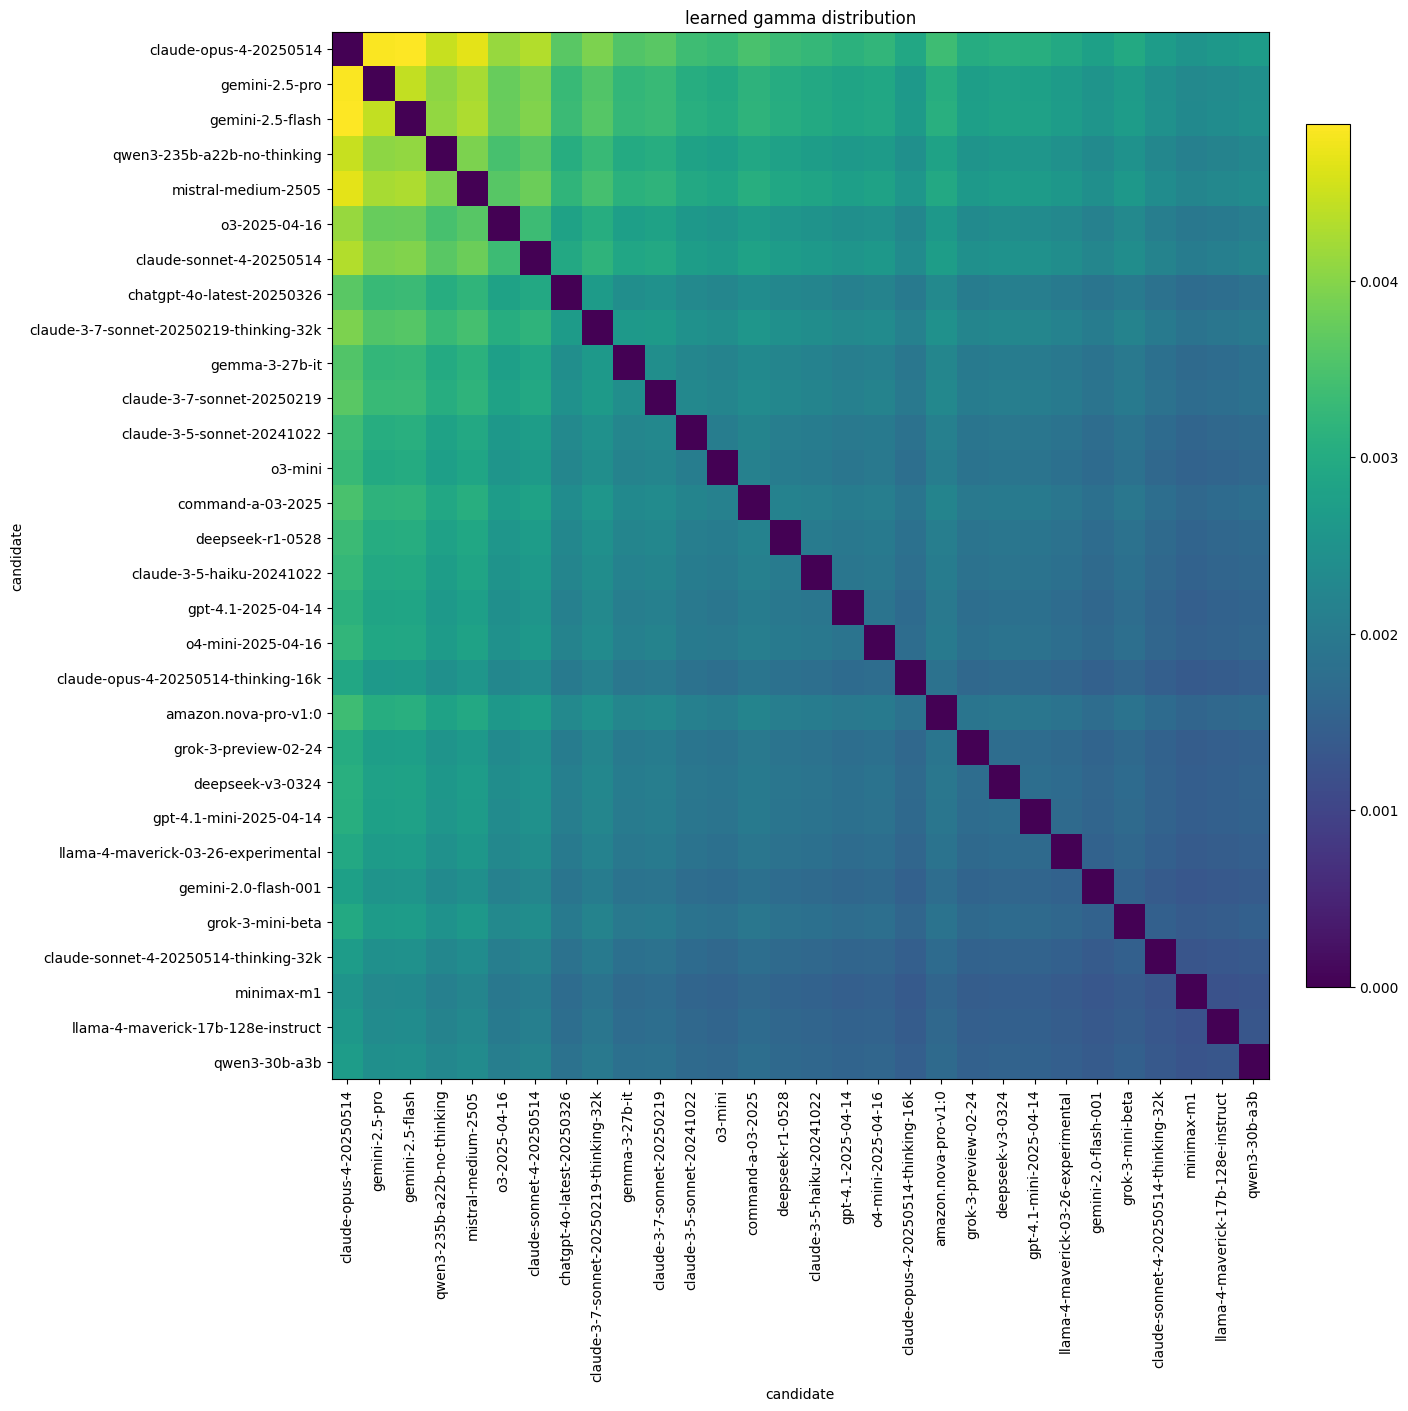

In [75]:
fig, axes = plt.subplots(1, 1, figsize=(14, 14), constrained_layout=True)

matrix = distr
title = "learned gamma distribution"

# for ax, (matrix, title) in zip(axes, heatmaps):
ax = axes
im = ax.imshow(matrix, cmap="viridis", aspect="auto")
ax.set_title(title)
ax.set_xlabel("candidate")
ax.set_ylabel("candidate")
ax.set_xticks(np.arange(len(candidate_labels)))
ax.set_yticks(np.arange(len(candidate_labels)))
ax.set_xticklabels(candidate_labels, rotation=90)
ax.set_yticklabels(candidate_labels)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

In [76]:
distr[np.triu_indices(distr.shape[0], k=0)].sum()

np.float64(0.999227947476522)

## Distortion

In [77]:
true_ranking = np.argsort(-population.avg_utilities)

In [36]:
from utils_3 import borda_from_population_utilities, leaderboard_dist
from scipy.special import expit


In [78]:
def borda_from_population_utilities_adjusted(utilities, voter_dist=None, cand_dist=None, beta=1.0):
    utilities = np.asarray(utilities)
    V, C = utilities.shape

    if voter_dist is None:
        voter_dist = np.ones(V, dtype=float) / V
    else:
        voter_dist = np.asarray(voter_dist, dtype=float)
        assert voter_dist.shape == (V,)
        voter_dist = voter_dist / voter_dist.sum()

    if cand_dist is None:
        cand_dist = np.ones(C, dtype=float) / C
    else:
        cand_dist = np.asarray(cand_dist, dtype=float)

    P = np.zeros((C, C), dtype=float)

    for v, u in enumerate(utilities):
        diffs = u[:, None] - u[None, :]
        P += voter_dist[v] * expit(beta * diffs)

    np.fill_diagonal(P, 0.0) # remove this?
    borda_scores = (P * cand_dist).sum(axis=1) # (m, m) @ (m, ...)
    ranking = np.argsort(-borda_scores)

    return borda_scores, ranking

In [98]:
def leaderboard_dist_w(ranking, true_ranking, avg_utils, w):
    ranking = np.asarray(ranking)
    true_ranking = np.asarray(true_ranking)

    ranking_utils = avg_utils[ranking]
    true_ranking_utils = avg_utils[true_ranking]

    # denom_cumsum = np.cumsum(ranking_utils)
    # num_cumsum = np.cumsum(true_ranking_utils)

    # ratio = np.max(num_cumsum / denom_cumsum)
    # k = np.argmax(num_cumsum / denom_cumsum)
    num = true_ranking_utils * w
    denom = ranking_utils * w

    ratio = num.sum() / denom.sum()

    return ratio, None

In [81]:
empirical_counts = np.zeros_like(gamma)

for i in range(len(pw.winners)):
    empirical_counts[pw.winners[i]] += 1
    empirical_counts[pw.losers[i]] += 1

empirical_distr = empirical_counts / empirical_counts.sum()

In [85]:
(pw.winners == pw.losers).sum()

np.int64(0)

/tmp/ipykernel_303035/3796369262.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


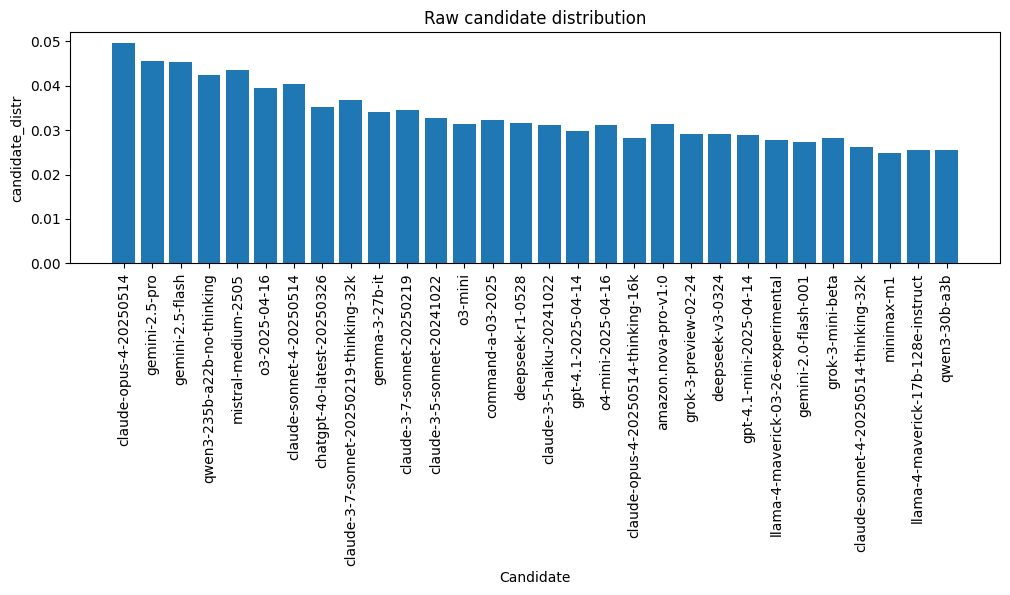

In [86]:
num_subgroups, num_candidates = population.population_utilities.shape
fig, axes = plt.subplots(1, 1, figsize=(12, max(3, 2.5 * 1)), squeeze=False)

for row_idx, ax in enumerate(axes[:, 0]):

    ax.bar(np.arange(num_candidates), empirical_distr)
    ax.set_title(f'Raw candidate distribution')
    ax.set_ylabel('candidate_distr')
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [88]:
cond_mu = mu.copy()

for i in range(len(mu)):
    cond_mu[i, ...] = mu[i, ...] / empirical_distr[i]

[ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 25 18  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 25 18  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 25 18  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 18 25  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 18 25  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7 20  5 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
  8 28 11 10 19 15]
[ 1 20  7  5 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
  8 28 11 10 19 15]
[ 1 20  7  5 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
  8 28 11 10 19 15]
[ 1  7 20  5 14  2 23  3 16 21  4 17  0 27 18 25  9 22 24 26 29 13  6 12
  8 28 11 10 19 15]


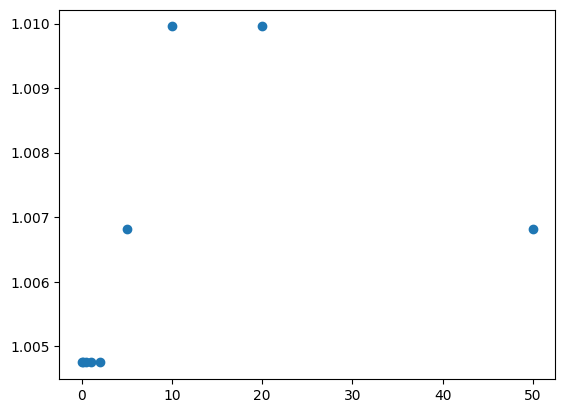

In [90]:
betas = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20, 50]
mu_leaderboard_distortions = []

print(true_ranking)

for beta in betas:
    borda_scores, borda_ranking = borda_from_population_utilities_adjusted(utilities=population.population_utilities, voter_dist=population.voter_distr, cand_dist=cond_mu, beta=beta)
    print(borda_ranking)
    distortion, k = leaderboard_dist(borda_ranking, true_ranking, population.avg_utilities)
    mu_leaderboard_distortions.append(distortion)


plt.scatter(x=np.asarray(betas), y=np.asarray(mu_leaderboard_distortions))
plt.show()

In [118]:
actual_distr = learned_gamma

In [122]:
actual_distr = np.zeros_like(mu)
for i in range(len(mu)):
    for j in range(len(mu)):
        if i != j:
            actual_distr[i, j] = learned_gamma[j]

In [124]:
actual_distr.sum()

np.float64(29.50680928566836)

In [125]:
cond_mu.sum()

np.float64(60.0)

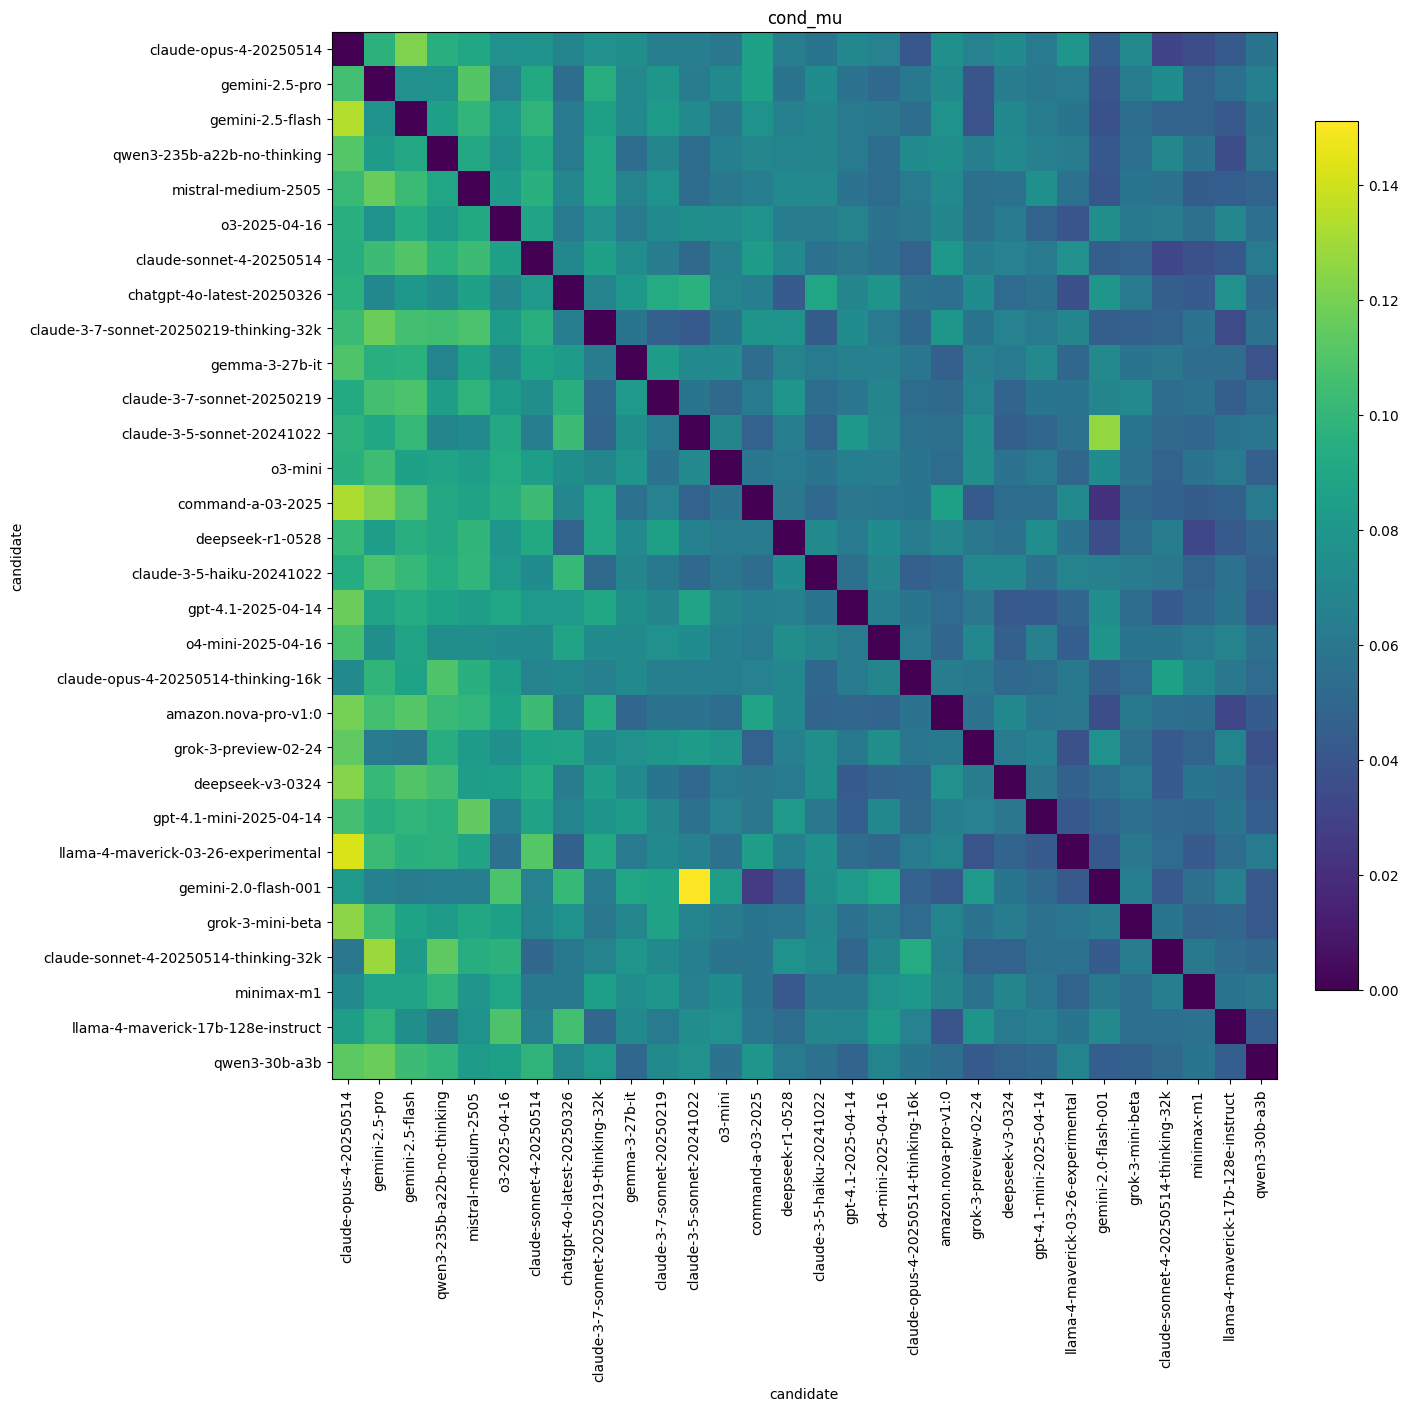

In [130]:
fig, axes = plt.subplots(1, 1, figsize=(14, 14), constrained_layout=True)

matrix = cond_mu
    # (mu, "mu"),
    # (2 * np.outer(learned_gamma, learned_gamma), "learned gamma"),
title = "cond_mu"

# for ax, (matrix, title) in zip(axes, heatmaps):

ax = axes
im = ax.imshow(matrix, cmap="viridis", aspect="auto")
ax.set_title(title)
ax.set_xlabel("candidate")
ax.set_ylabel("candidate")
ax.set_xticks(np.arange(len(candidate_labels)))
ax.set_yticks(np.arange(len(candidate_labels)))
ax.set_xticklabels(candidate_labels, rotation=90)
ax.set_yticklabels(candidate_labels)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

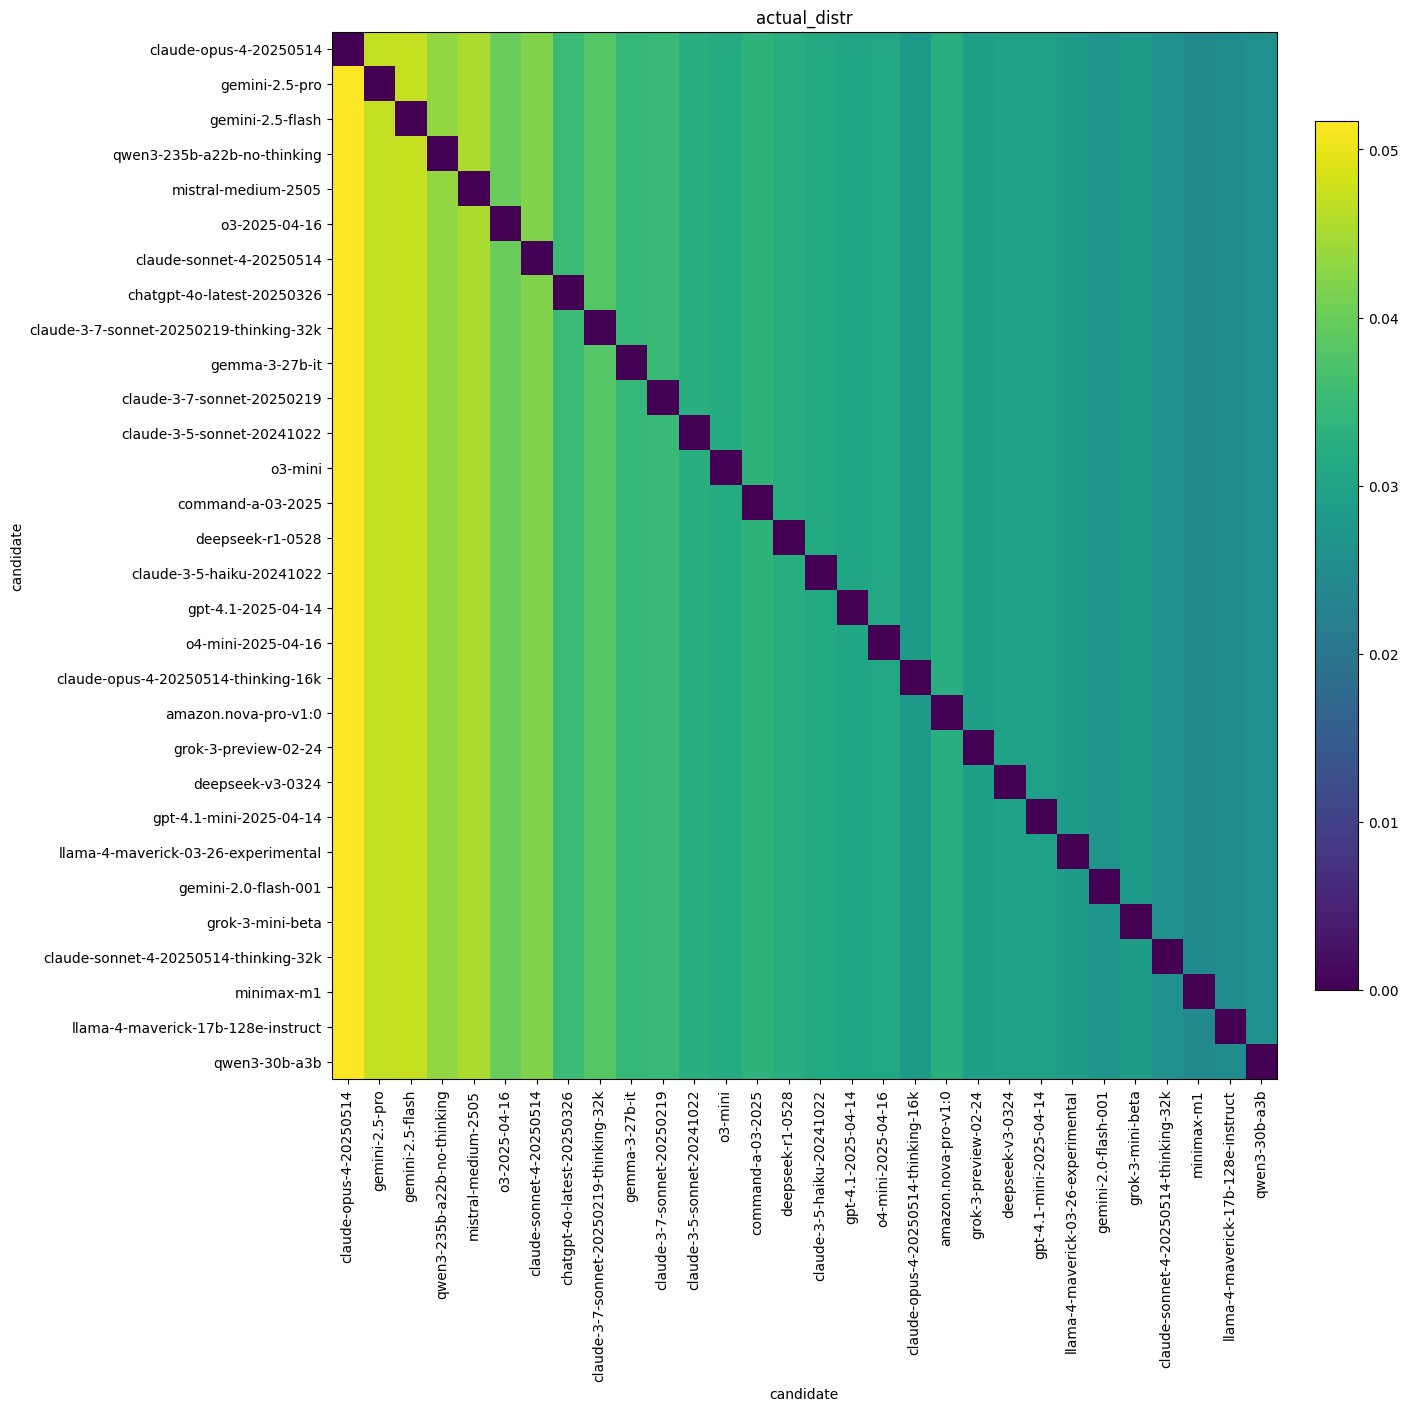

In [131]:
fig, axes = plt.subplots(1, 1, figsize=(14, 14), constrained_layout=True)

matrix = actual_distr
    # (mu, "mu"),
    # (2 * np.outer(learned_gamma, learned_gamma), "learned gamma"),
title = "actual_distr"

# for ax, (matrix, title) in zip(axes, heatmaps):

ax = axes
im = ax.imshow(matrix, cmap="viridis", aspect="auto")
ax.set_title(title)
ax.set_xlabel("candidate")
ax.set_ylabel("candidate")
ax.set_xticks(np.arange(len(candidate_labels)))
ax.set_yticks(np.arange(len(candidate_labels)))
ax.set_xticklabels(candidate_labels, rotation=90)
ax.set_yticklabels(candidate_labels)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

[ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 25 18  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 18 25  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 18 25  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7 20  5 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
  8 28 11 10 19 15]
[ 1 20  7  5 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
  8 28 11 10 19 15]
[ 1 20  7  5 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
  8 28 11 10 19 15]
[ 1  7 20  5 14  2 23  3 16 21  4 17  0 27 18 25  9 22 24 26 29 13  6 12
  8 28 11 10 19 15]
[ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]
[ 1 20  7  5 14 23  2 16  3 21 17  4 27 18 25  9  0 26 22 29 24 13  6 12
 28  8 11 10 19 15]
[ 1 20  7  5 14 23  2  3 16 21 17  4 27 18  0 25  9 26 22 24 29 13  6 

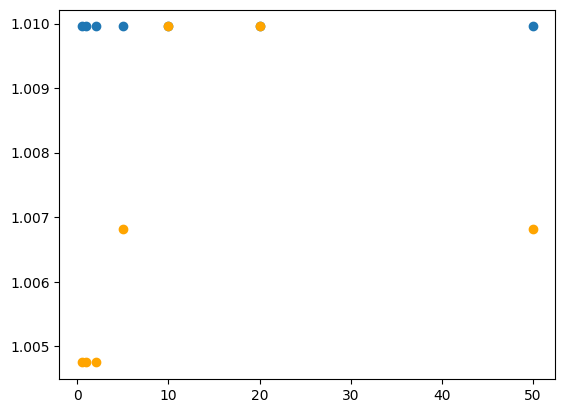

In [129]:
betas = [0.5, 1.0, 2.0, 5.0, 10.0, 20, 50]

mu_leaderboard_distortions = []

print(true_ranking)

for beta in betas:
    borda_scores, borda_ranking = borda_from_population_utilities_adjusted(utilities=population.population_utilities, voter_dist=population.voter_distr, cand_dist=cond_mu, beta=beta)
    print(borda_ranking)
    distortion, k = leaderboard_dist(borda_ranking, true_ranking, population.avg_utilities)
    mu_leaderboard_distortions.append(distortion)

gamma_leaderboard_distortions = []

print(true_ranking)

for beta in betas:
    borda_scores, borda_ranking = borda_from_population_utilities_adjusted(utilities=population.population_utilities, voter_dist=population.voter_distr, cand_dist=actual_distr, beta=beta)
    print(borda_ranking)
    distortion, k = leaderboard_dist(borda_ranking, true_ranking, population.avg_utilities)
    gamma_leaderboard_distortions.append(distortion)


plt.scatter(x=np.asarray(betas), y=np.asarray(gamma_leaderboard_distortions))
plt.scatter(x=np.asarray(betas), y=np.asarray(mu_leaderboard_distortions), c='orange')

plt.show()

In [49]:
adjusted_mu = mu.copy()

for i in range(len(empirical_distr)):
    adjusted_mu[i, ...] = adjusted_mu[i, ...] / empirical_distr[i]

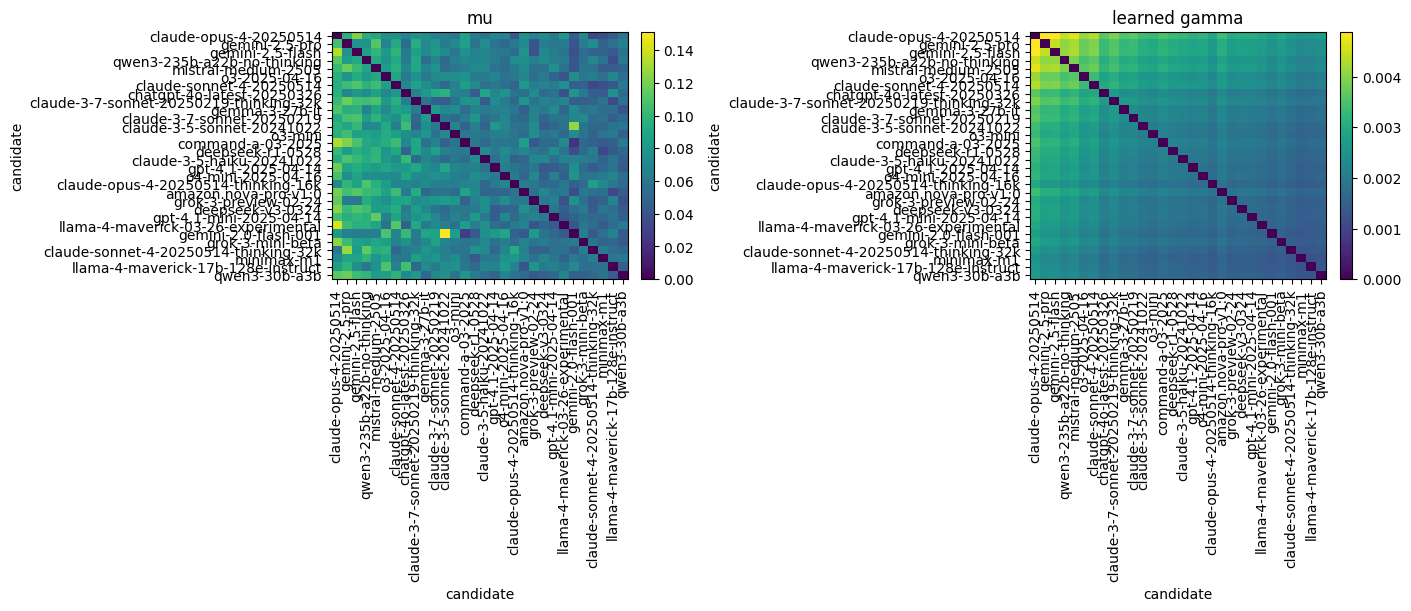

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

heatmaps = [
    (adjusted_mu, "mu"),
    (distr, "learned gamma"),
]

for ax, (matrix, title) in zip(axes, heatmaps):
    im = ax.imshow(matrix, cmap="viridis", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("candidate")
    ax.set_ylabel("candidate")
    ax.set_xticks(np.arange(len(candidate_labels)))
    ax.set_yticks(np.arange(len(candidate_labels)))
    ax.set_xticklabels(candidate_labels, rotation=90)
    ax.set_yticklabels(candidate_labels)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

In [52]:
mu.sum()

np.float64(2.0)

## Comparison of distributions

In [114]:
distr.shape

(30, 30)

In [116]:
distr.sum()

np.float64(1.998455894953044)

In [117]:
cond_mu.sum()

np.float64(60.0)

/tmp/ipykernel_303035/2676659838.py:23: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


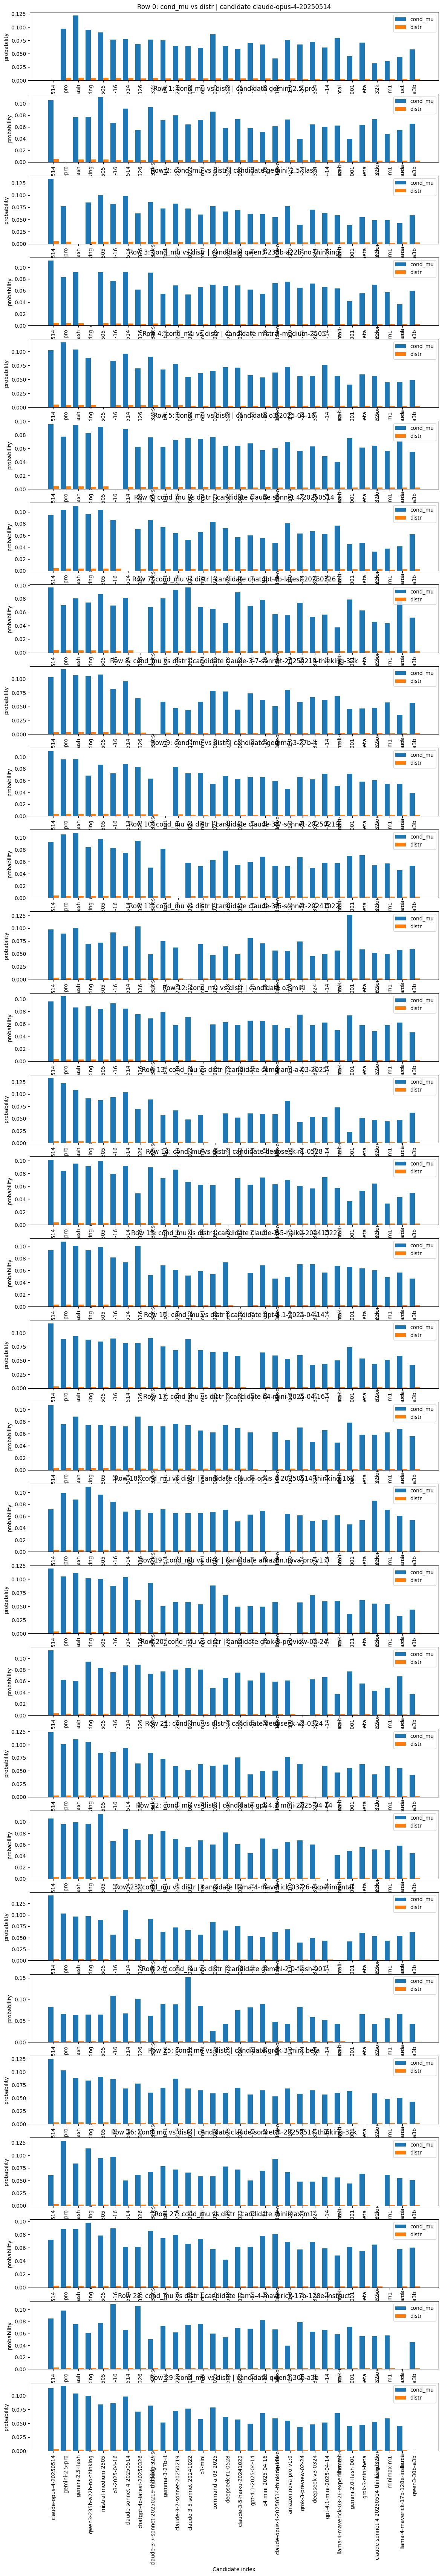

In [115]:
x = np.arange(cond_mu.shape[1])
width = 0.42
# winner_labels = observed_winner_labels if 'observed_winner_labels' in locals() else observed_candidate_labels
winner_labels = candidate_labels

fig, axes = plt.subplots(
    cond_mu.shape[0],
    1,
    figsize=(14, max(3, 2.8 * cond_mu.shape[0])),
    squeeze=False,
)

for row_idx, ax in enumerate(axes[:, 0]):
    ax.bar(x - width / 2, cond_mu[row_idx, ...], width=width, label='cond_mu')
    ax.bar(x + width / 2, distr[row_idx, ...], width=width, label='distr')
    ax.set_title(f'Row {row_idx}: cond_mu vs distr | candidate {winner_labels[row_idx]}')
    ax.set_ylabel('probability')
    ax.set_xticks(x)
    ax.set_xticklabels(candidate_labels, rotation=90)
    ax.legend()

axes[-1, 0].set_xlabel('Candidate index')
plt.tight_layout()
plt.show()


## With fixed weight set

In [100]:
w = 1 / (1.1 ** np.arange(len(borda_ranking)))

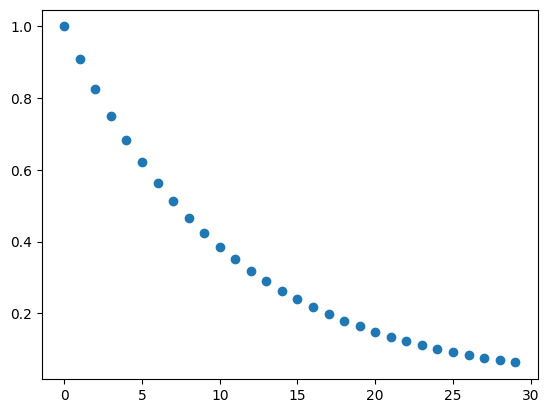

In [101]:
plt.scatter(x=np.arange(len(w)), y=w)

[ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 25 18  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 25 18  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 25 18  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 18 25  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 18 25  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7 20  5 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
  8 28 11 10 19 15]
[ 1 20  7  5 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
  8 28 11 10 19 15]
[ 1 20  7  5 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
  8 28 11 10 19 15]
[ 1  7 20  5 14  2 23  3 16 21  4 17  0 27 18 25  9 22 24 26 29 13  6 12
  8 28 11 10 19 15]


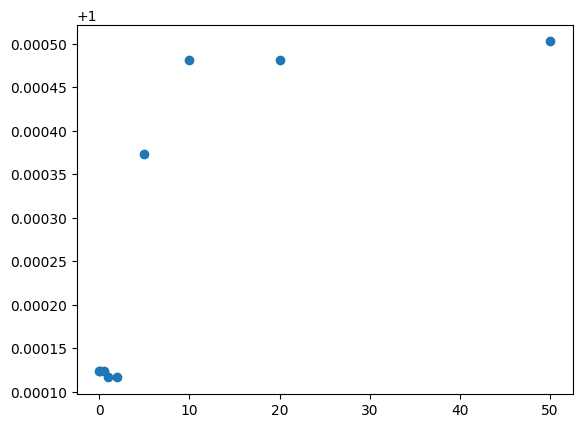

In [102]:
betas = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20, 50]
mu_leaderboard_distortions = []

print(true_ranking)

for beta in betas:
    borda_scores, borda_ranking = borda_from_population_utilities_adjusted(utilities=population.population_utilities, voter_dist=population.voter_distr, cand_dist=cond_mu, beta=beta)
    print(borda_ranking)
    
    
    distortion, k = leaderboard_dist_w(ranking=borda_ranking, true_ranking=true_ranking, avg_utils=population.avg_utilities, w=w)
    mu_leaderboard_distortions.append(distortion)


plt.scatter(x=np.asarray(betas), y=np.asarray(mu_leaderboard_distortions))
plt.show()